In [4]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm # Dùng cho Phần 2 câu 3

# Cấu hình hiển thị đồ thị đẹp hơn
sns.set_theme(style="whitegrid")

# Tải dữ liệu Iris từ Seaborn
df = sns.load_dataset("iris")

In [6]:
# 1. Hiển thị thông tin cơ bản
print("5 dòng đầu tiên:")
print(df.head())
print(f"\nSố dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("\nKiểu dữ liệu các cột:")
print(df.dtypes)

# 2. Tính toán đặc trưng cho các biến số
# Lọc ra các cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Tạo một DataFrame để lưu kết quả cho gọn gàng
stats_df = pd.DataFrame()
stats_df['mean'] = df[numeric_cols].mean()
stats_df['median'] = df[numeric_cols].median()
stats_df['mode'] = df[numeric_cols].apply(lambda x: x.mode()[0]) # Lấy giá trị mode đầu tiên
stats_df['var'] = df[numeric_cols].var()
stats_df['std'] = df[numeric_cols].std()
stats_df['min'] = df[numeric_cols].min()
stats_df['max'] = df[numeric_cols].max()
stats_df['Q1'] = df[numeric_cols].quantile(0.25)
stats_df['Q3'] = df[numeric_cols].quantile(0.75)
stats_df['IQR'] = stats_df['Q3'] - stats_df['Q1']

print("\nBảng thống kê mô tả:")
print(stats_df.T)

5 dòng đầu tiên:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Số dòng: 150, Số cột: 5

Kiểu dữ liệu các cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Bảng thống kê mô tả:
        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
median      5.800000     3.000000      4.350000     1.300000
mode        5.000000     3.000000      1.400000     0.200000
var         0.685694     0.189979      3.116278     0.581006
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.00

In [7]:
# 3. Gom nhóm theo species và tính mean, std
grouped_stats = df.groupby('species').agg(['mean', 'std'])
print("\nThống kê theo từng nhóm loài hoa:")
print(grouped_stats)


Thống kê theo từng nhóm loài hoa:
           sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650  


Nhận xét về sự khác biệt giữa các loài hoa:

+Loài hoa có sự khác biệt rõ rệt nhất là setosa: Kích thước petal_length và petal_width của loài này nhỏ hơn hẳn và tách biệt hoàn toàn so với hai loài còn lại.

+Sự tương đồng giữa hai loài còn lại: Loài versicolor và virginica có các chỉ số sepal và petal khá gần nhau, không có sự chênh lệch quá nhiều như setosa.

+Độ lệch chuẩn (std): về kích thước cánh hoa của setosa cũng là thấp nhất (chỉ khoảng 0.17 và 0.10), chứng tỏ các bông hoa thuộc loài setosa có kích thước rất đồng đều nhau, ít bị biến động.

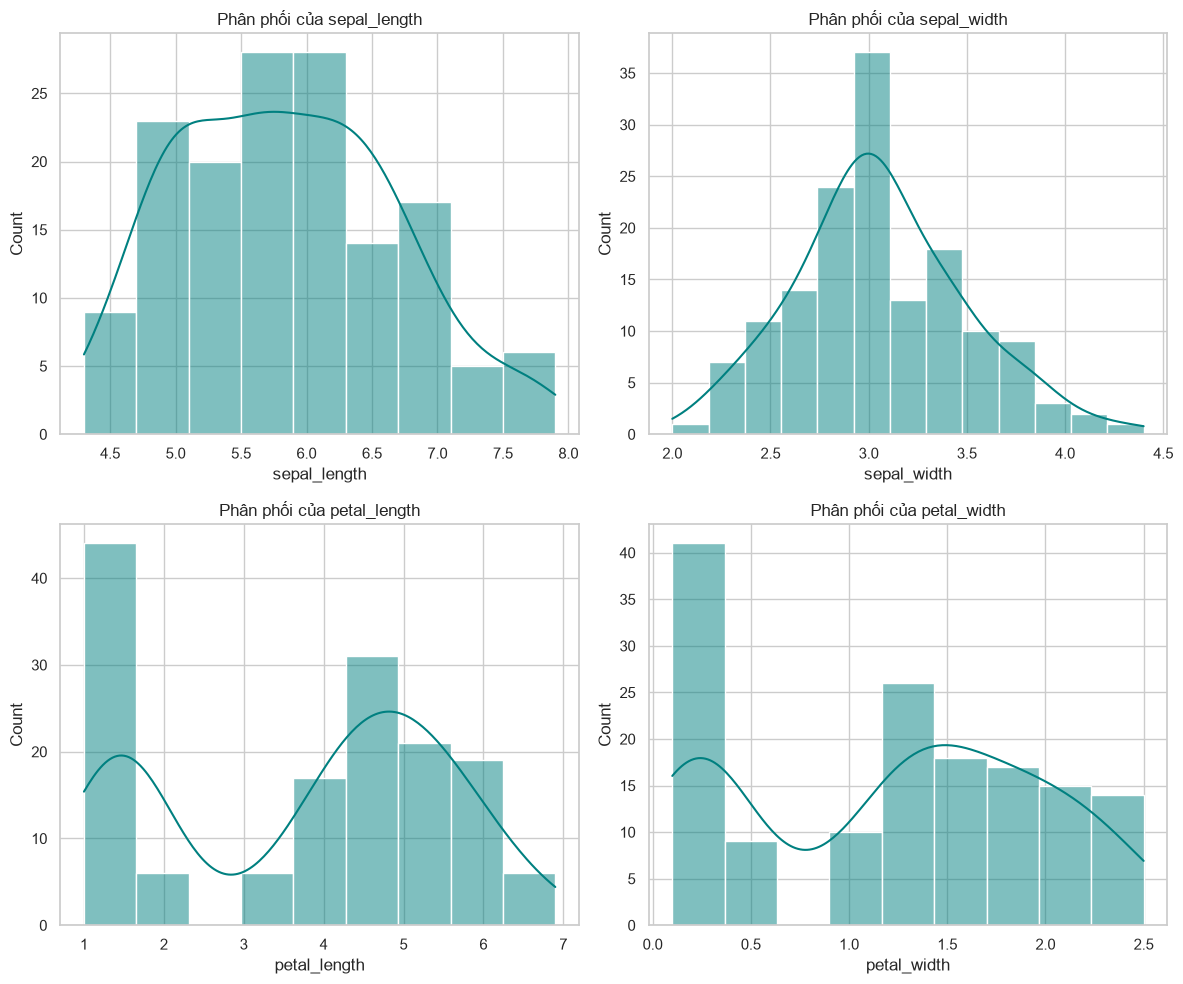

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

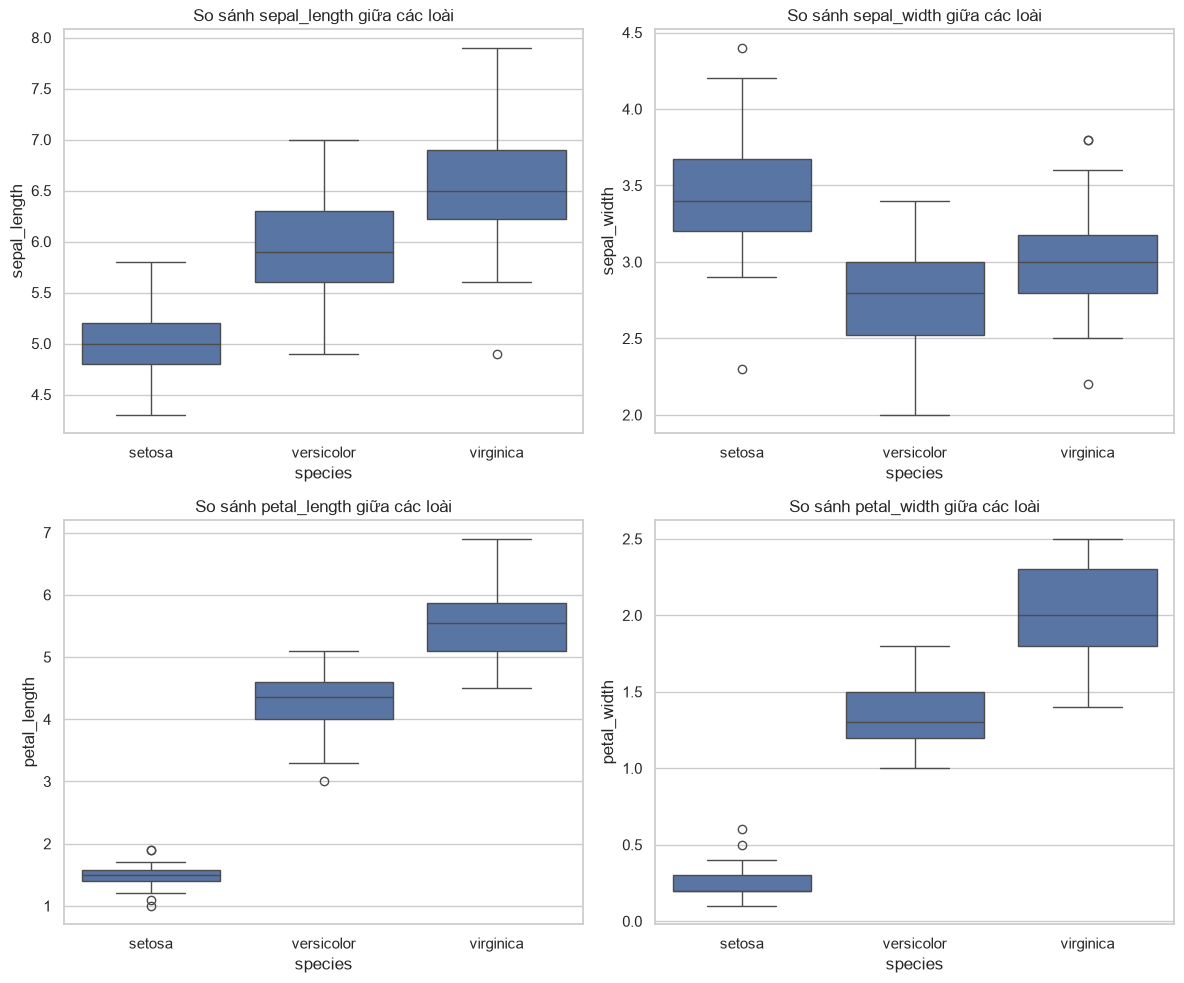

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i])
    axes[i].set_title(f'So sánh {col} giữa các loài')

plt.tight_layout()
plt.show()

Nhận xét hình dạng phân phối:

Các biến đài hoa (sepal_length và sepal_width): Đồ thị có hình dáng cái chuông khá cân xứng, đỉnh nằm ở giữa, do đó có thể coi là gần với phân phối chuẩn.

Các biến cánh hoa (petal_length và petal_width): Đồ thị bị đứt quãng và có 2 đỉnh rõ rệt. Đây là dạng phân phối nhiều đỉnh (bimodal), nguyên nhân là do kích thước cánh hoa của loài setosa quá nhỏ nên tự tách thành một đỉnh riêng biệt so với hai loài còn lại.

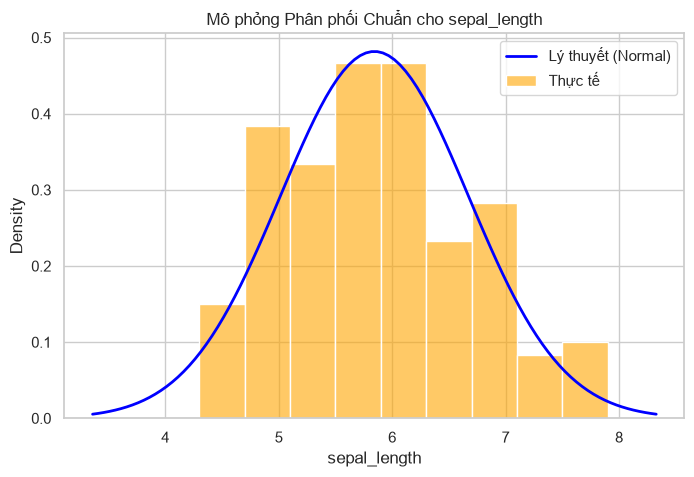

In [10]:
col_chosen = 'sepal_length'
mu = df[col_chosen].mean()
sigma = df[col_chosen].std()

# Sinh mẫu ngẫu nhiên từ phân phối chuẩn lý thuyết
simulated_data = np.random.normal(mu, sigma, size=10000)

plt.figure(figsize=(8, 5))
# Vẽ histogram dữ liệu thực tế (dạng mật độ - density)
sns.histplot(df[col_chosen], stat="density", kde=False, label="Thực tế", color='orange', alpha=0.6)

# Vẽ đường PDF lý thuyết
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, norm.pdf(x, mu, sigma), color='blue', linewidth=2, label="Lý thuyết (Normal)")

plt.title(f'Mô phỏng Phân phối Chuẩn cho {col_chosen}')
plt.legend()
plt.show()

Nhận xét mức độ khớp:
Đường cong phân phối chuẩn lý thuyết (đường PDF) ôm khá sát với hình dạng của biểu đồ cột histogram dữ liệu thực tế. Điều này chứng tỏ biến sepal_length xấp xỉ phân phối chuẩn rất tốt.

Ma trận tương quan:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


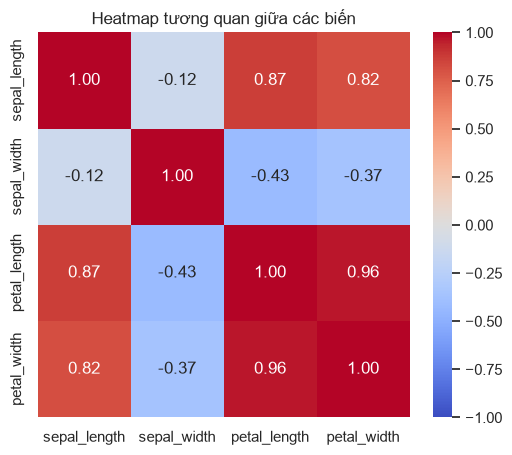

In [11]:
# 1. Tính ma trận hiệp phương sai và tương quan
cov_matrix = df[numeric_cols].cov()
corr_matrix = df[numeric_cols].corr()

print("Ma trận tương quan:")
print(corr_matrix)

# 2. Vẽ Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap tương quan giữa các biến")
plt.show()

Nhận xét ma trận tương quan:

Cặp biến tương quan mạnh nhất: Là petal_length và petal_width với hệ số tương quan lên tới khoảng 0.96. Nghĩa là cánh hoa càng dài thì gần như chắc chắn nó sẽ càng rộng (tỉ lệ thuận cực kỳ mạnh).

Dấu hiệu đa cộng tuyến: Dữ liệu này có dấu hiệu đa cộng tuyến rất mạnh. Các biến đo lường cánh hoa (petal) đều có hệ số tương quan lớn hơn 0.8 với nhau. Nếu ta đưa tất cả các biến này vào cùng một mô hình Học máy (Machine Learning), mô hình sẽ bị dư thừa và trùng lặp thông tin.

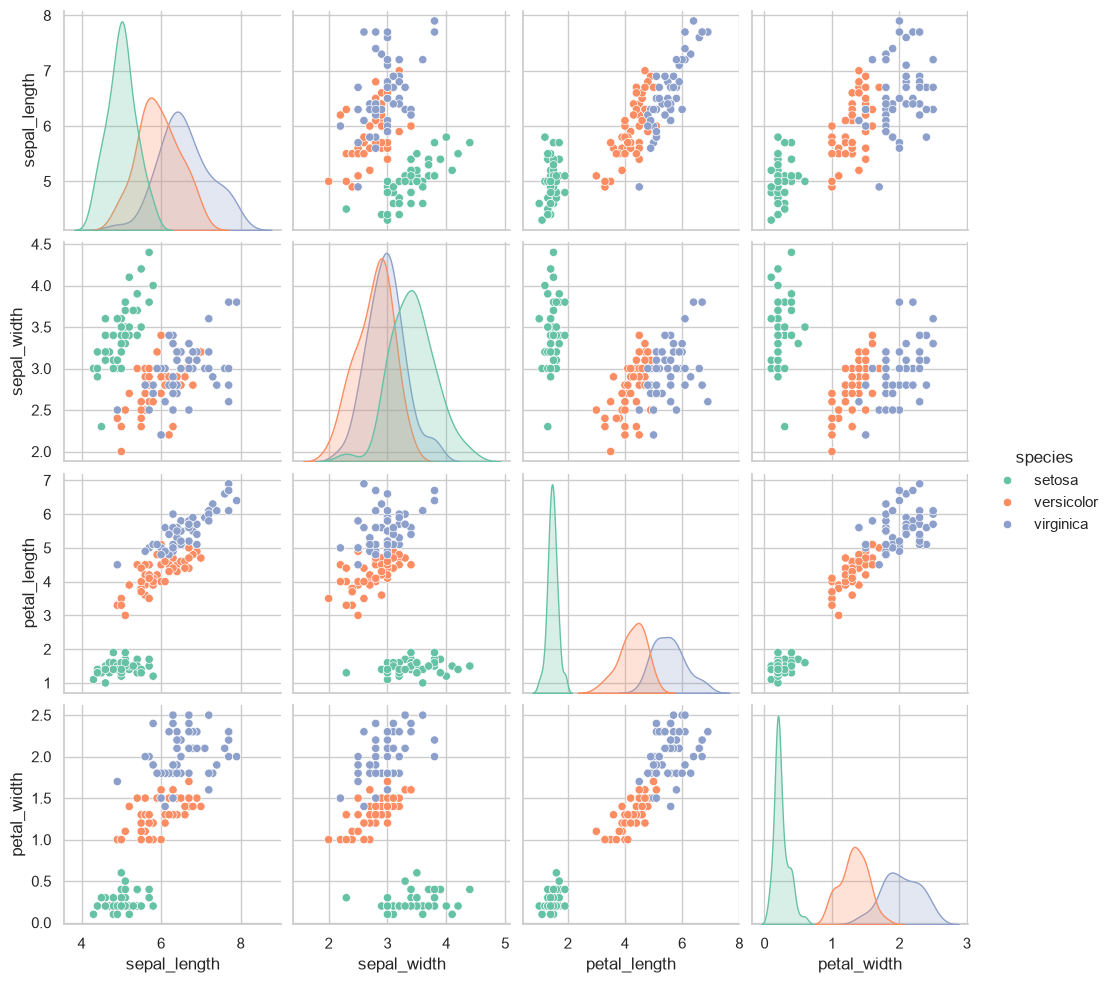

In [12]:
sns.pairplot(df, hue='species', diag_kind='kde', palette='Set2')
plt.show()

Nhận xét quan hệ giữa các biến theo loài:

Nhìn vào các biểu đồ phân tán (scatter), các chấm dữ liệu của loài setosa luôn tách biệt hoàn toàn thành một cụm riêng ở một góc.

Các chấm dữ liệu của hai loài versicolor và virginica thì bám sát nhau hơn và có một chút xen lẫn (overlap) ở vùng ranh giới.

Nhìn chung, các cặp biến cánh hoa tạo thành đường chéo hướng lên, thể hiện mối quan hệ tuyến tính (tỉ lệ thuận) rất rõ ràng.

In [13]:
# Khai báo các xác suất ban đầu
P_B = 0.01                 # Tỉ lệ mắc bệnh P(B)
P_pos_givenB = 0.99        # Độ nhạy P(+|B)
P_pos_givenNB = 0.05       # Dương tính giả P(+|~B)

# 1. Tính P(+) bằng công thức xác suất đầy đủ
P_pos = (P_pos_givenB * P_B) + (P_pos_givenNB * (1 - P_B))

# Tính P(B|+) bằng định lý Bayes
P_B_given_pos = (P_pos_givenB * P_B) / P_pos

print(f"Xác suất một người thực sự mắc bệnh khi có kết quả xét nghiệm dương tính: {round(P_B_given_pos, 4)}")

Xác suất một người thực sự mắc bệnh khi có kết quả xét nghiệm dương tính: 0.1667


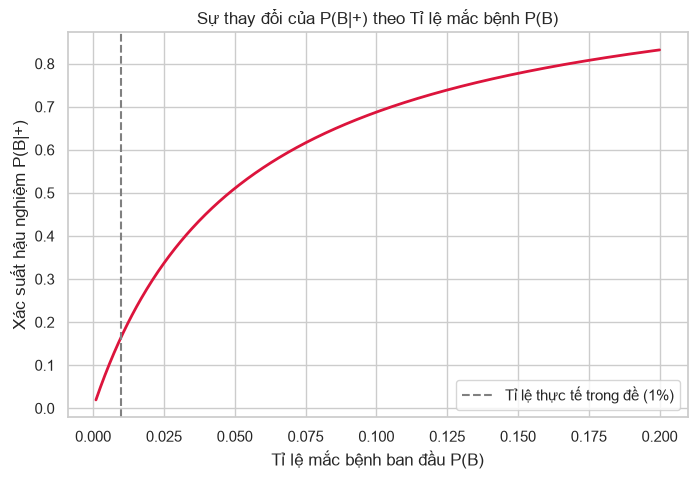

In [14]:
# Tạo mảng P(B) chạy từ 0.001 đến 0.2
P_B_space = np.linspace(0.001, 0.2, 500)

# Tính P(B|+) tương ứng với từng giá trị P(B)
P_B_given_pos_space = (P_pos_givenB * P_B_space) / ((P_pos_givenB * P_B_space) + (P_pos_givenNB * (1 - P_B_space)))

# Vẽ đồ thị khảo sát
plt.figure(figsize=(8, 5))
plt.plot(P_B_space, P_B_given_pos_space, color='crimson', linewidth=2)
plt.xlabel("Tỉ lệ mắc bệnh ban đầu P(B)")
plt.ylabel("Xác suất hậu nghiệm P(B|+)")
plt.title("Sự thay đổi của P(B|+) theo Tỉ lệ mắc bệnh P(B)")
plt.axvline(x=0.01, color='gray', linestyle='--', label='Tỉ lệ thực tế trong đề (1%)')
plt.legend()
plt.show()

Giải thích hiện tượng:
Nhìn vào đồ thị ta thấy, khi căn bệnh cực kỳ hiếm gặp (tỉ lệ $P(B)$ rất thấp), xác suất một người thực sự mắc bệnh dù đã xét nghiệm dương tính lại rất thấp (chỉ khoảng 16%).
Nguyên nhân là do dân số không mắc bệnh quá đông. Dù máy xét nghiệm xịn đến đâu (tỉ lệ sai sót chỉ 5%), thì 5% dương tính giả của một tỉ người không bệnh vẫn là một con số khổng lồ, áp đảo hoàn toàn số lượng ít ỏi những người thực sự mắc bệnh. Do đó, đa số những người nhận tờ kết quả "Dương tính" thực chất là những người khỏe mạnh bị chẩn đoán nhầm.